In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
df=pd.read_csv("EasyVisa.csv")

In [3]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [4]:
df.shape

(25480, 12)

In [5]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [8]:
# Define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']

categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# Print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))

print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

We have 9 categorical features : ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [10]:
# proportion of count data on categorical columns
for col in categorical_features:
  print(df[col].value_counts(normalize=True) * 100)
  print('---------------------------')

case_id
EZYV01       0.003925
EZYV16995    0.003925
EZYV16993    0.003925
EZYV16992    0.003925
EZYV16991    0.003925
               ...   
EZYV8492     0.003925
EZYV8491     0.003925
EZYV8490     0.003925
EZYV8489     0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
---------------------------
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
---------------------------
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
---------------------------
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
---------------------------
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
---------------------------
region_of_employment
Northeast    2

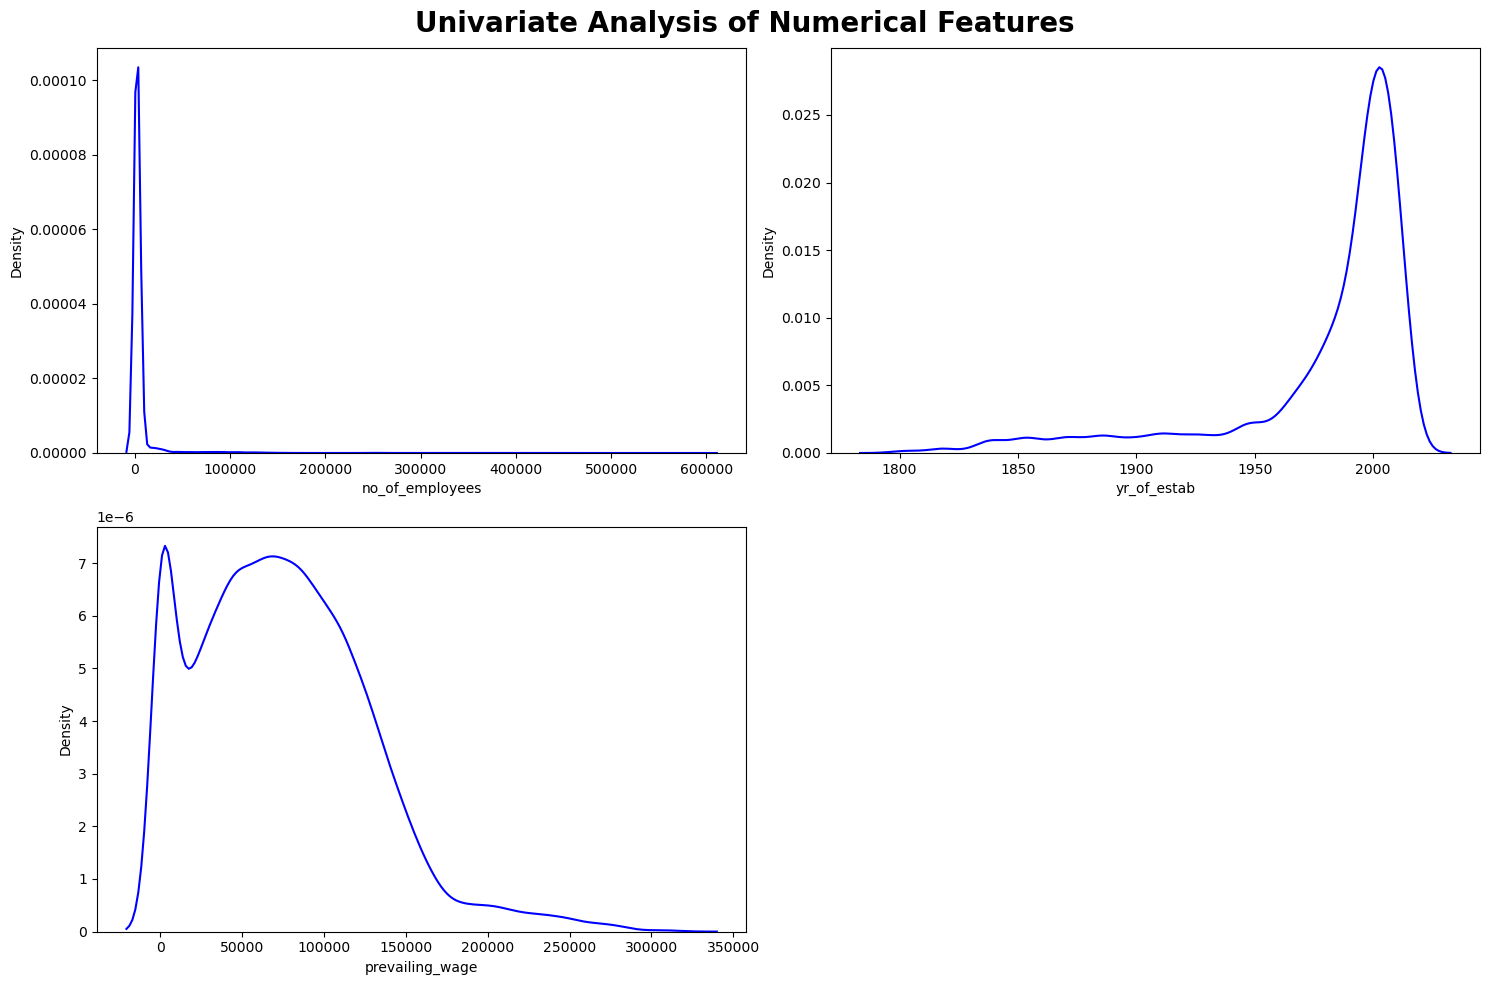

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.figure(figsize=(15, 10))

# Main title
plt.suptitle('Univariate Analysis of Numerical Features',
             fontsize=20,
             fontweight='bold')

# Loop through numerical features
for i in range(0, len(numeric_features)):
    
    # Create subplot
    plt.subplot(2, 2, i + 1)
    
    # KDE plot
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    
    # X-axis label
    plt.xlabel(numeric_features[i])

# Adjust layout
plt.tight_layout()

# Save plot (optional)
# plt.savefig('./images/Univariate_Num.png')

# Show plot
plt.show()

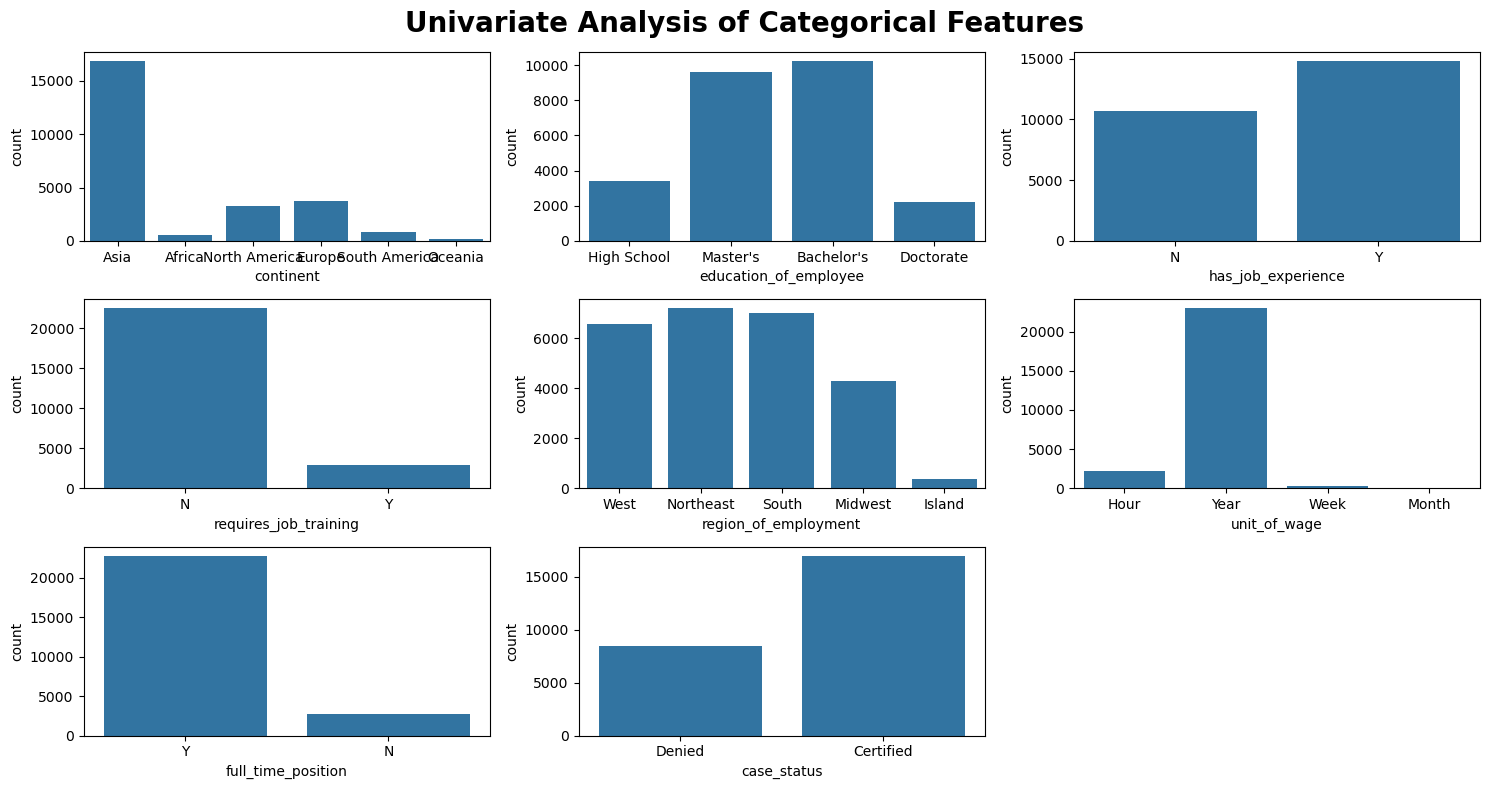

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove 'case_id' from categorical columns
categorical_features.remove('case_id')

# Create figure
plt.figure(figsize=(15, 8))

# Main title
plt.suptitle('Univariate Analysis of Categorical Features',
             fontsize=20,
             fontweight='bold')

# Loop through categorical features
for i in range(0, len(categorical_features)):
    
    # Create subplot
    plt.subplot(3, 3, i + 1)
    
    # Count plot
    sns.countplot(x=df[categorical_features[i]])
    
    # X-axis label
    plt.xlabel(categorical_features[i])

# Adjust layout
plt.tight_layout()

# Save plot (optional)
# plt.savefig('./images/Univariate_Cat.png')

# Show plot
plt.show()

In [14]:
# Multivariate analysis is the analysis of more than one variable

# Find discrete features
discrete_features = [feature for feature in numeric_features 
                     if len(df[feature].unique()) < 25]

# Find continuous features
continuous_features = [feature for feature in numeric_features 
                       if len(df[feature].unique()) >= 25]

# Print discrete features
print('We have {} discrete features : {}'.format(
    len(discrete_features), discrete_features))

# Print continuous features
print('\nWe have {} continuous features : {}'.format(
    len(continuous_features), continuous_features))

We have 0 discrete features : []

We have 3 continuous features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


In [15]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [19]:
from scipy.stats import chi2_contingency
chi2_test = []
for feature in categorical_features:
 if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] < 0.05:
  chi2_test.append('Reject Null Hypothesis')
 else:
  chi2_test.append('Fail to Reject Null Hypothesis')
result = pd.DataFrame(data=[categorical_features, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']
result

,Column,Hypothesis Result
0,continent,Reject Null Hypothesis
1,education_of_employee,Reject Null Hypothesis
2,has_job_experience,Reject Null Hypothesis
3,requires_job_training,Fail to Reject Null Hypothesis
4,region_of_employment,Reject Null Hypothesis
5,unit_of_wage,Reject Null Hypothesis
6,full_time_position,Reject Null Hypothesis
7,case_status,Reject Null Hypothesis


In [20]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [21]:
# Find continuous features
continuous_features = [feature for feature in numeric_features 
                       if len(df[feature].unique()) >= 25]

# Print continuous features
print('Num of continuous features :', continuous_features)

Num of continuous features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


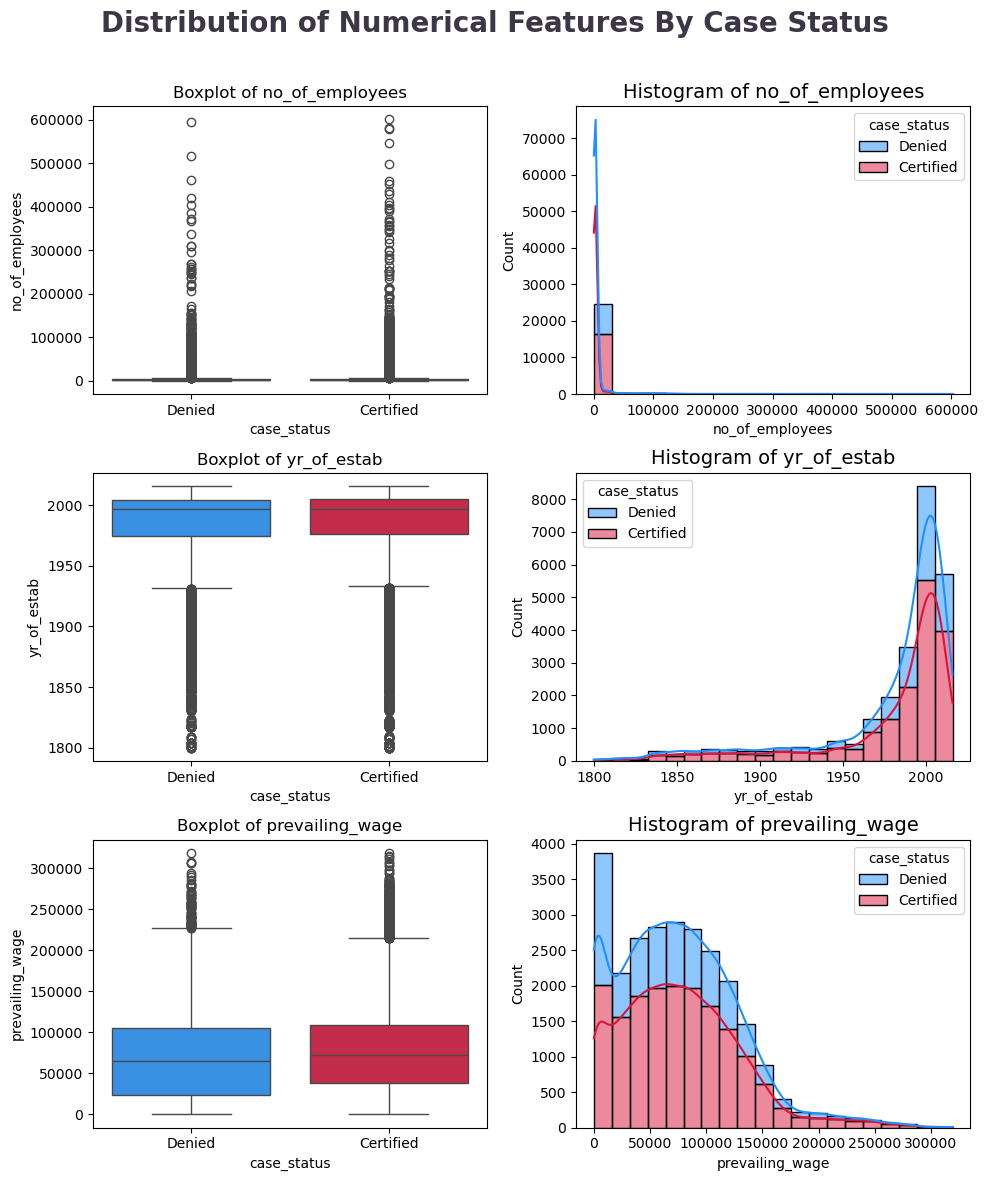

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Color palette
clr1 = ['#1E90FF', '#DC143C']

# Create subplots
fig, ax = plt.subplots(3, 2, figsize=(10, 12))

# Main title
fig.suptitle('Distribution of Numerical Features By Case Status',
             color='#3C3744',
             fontsize=20,
             fontweight='bold',
             ha='center')

# Loop through continuous features
for i, col in enumerate(continuous_features):

    # Boxplot
    sns.boxplot(data=df,
                x='case_status',
                y=col,
                palette=clr1,
                ax=ax[i, 0])

    ax[i, 0].set_title(f'Boxplot of {col}', fontsize=12)

    # Histogram
    sns.histplot(data=df,
                 x=col,
                 hue='case_status',
                 bins=20,
                 kde=True,
                 multiple='stack',
                 palette=clr1,
                 ax=ax[i, 1])

    ax[i, 1].set_title(f'Histogram of {col}', fontsize=14)

# Adjust layout
fig.tight_layout()

# Adjust top spacing
fig.subplots_adjust(top=0.90)

# Save plot (optional)
# plt.savefig('images/multivariate_num.png')

# Show plot
plt.show()

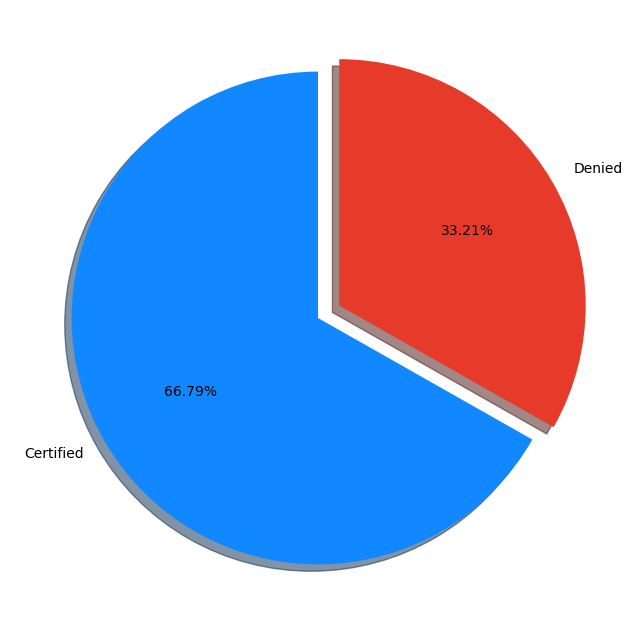

In [23]:
percentage = df.case_status.value_counts(normalize=True)*100
labels = ["Certified","Denied"]
# Plot PieChart with Ploty library
fig, ax = plt.subplots(figsize =(15, 8))
explode = (0, 0.1)
colors = ['#1188ff','#e63a2a']
ax.pie(percentage, labels = labels, startangle = 90,
autopct='%1.2f%%',explode=explode, shadow=True, colors=colors)
plt.show()

In [24]:

#group data by continent and their count of case_status
df.groupby('continent')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

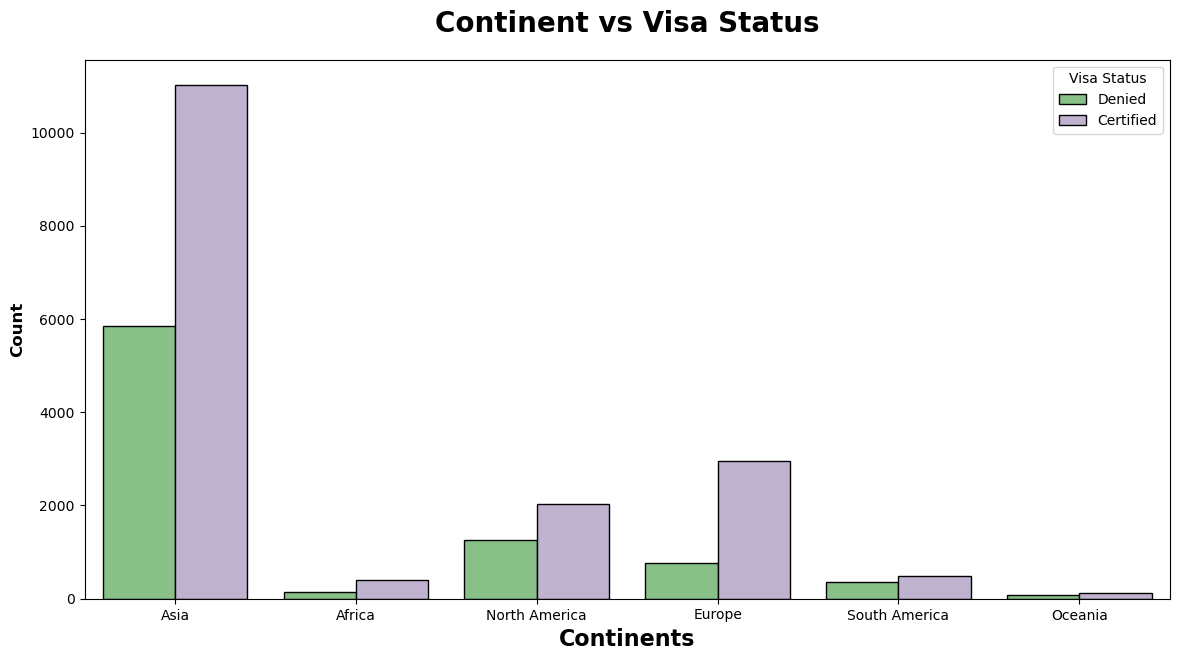

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.subplots(figsize=(14, 7))

# Count plot
sns.countplot(x="continent",
              hue="case_status",
              data=df,
              ec="black",
              palette="Accent")

# Title
plt.title("Continent vs Visa Status",
          weight="bold",
          fontsize=20,
          pad=20)

# Y-axis label
plt.ylabel("Count",
           weight="bold",
           fontsize=12)

# X-axis label
plt.xlabel("Continents",
           weight="bold",
           fontsize=16)

# Legend
plt.legend(title="Visa Status",
           fancybox=True)

# Show plot
plt.show()

In [26]:

df2 = df.copy()

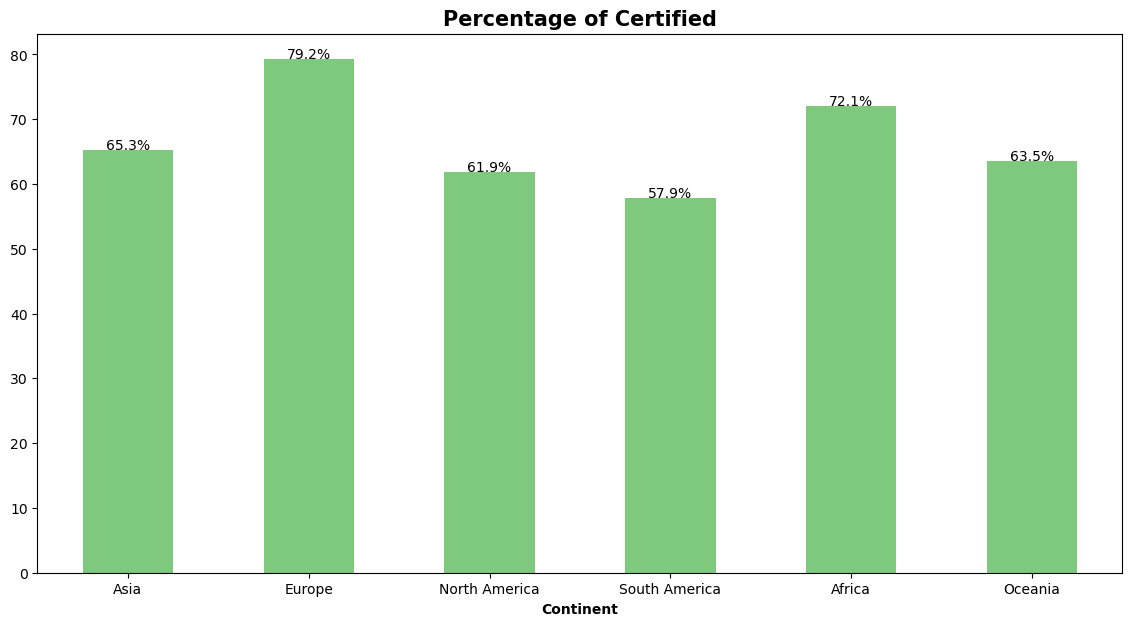

In [27]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=[14, 7])

# Calculate percentage of Certified cases by continent
certified_percent = (
    100 * df2[df2["case_status"].isin(['Certified'])]['continent'].value_counts()
    / df2['continent'].value_counts()
)

# Plot bar chart
certified_percent.plot(
    kind='bar',
    stacked=True,
    colormap='Accent'
)

# Title
plt.title("Percentage of Certified",
          fontsize=15,
          fontweight='bold')

# Store values for annotation
order1 = certified_percent.values

# Add percentage text on bars
for n in range(len(order1)):
    count = order1[n]
    strt = '{:0.1f}%'.format(count)
    
    plt.text(n, count + 0.1, strt, ha='center')

# X-axis label
plt.xlabel('Continent',
           fontweight='bold')

# Rotate x labels
plt.xticks(rotation=0)

# Show plot
plt.show()

In [28]:
# Group data by education and case status
education_case_status = (
    df.groupby('education_of_employee')['case_status']
      .value_counts(normalize=True)
      .to_frame()
)

# Display output
print(education_case_status)

                                   proportion
education_of_employee case_status            
Bachelor's            Certified      0.622142
                      Denied         0.377858
Doctorate             Certified      0.872263
                      Denied         0.127737
High School           Denied         0.659649
                      Certified      0.340351
Master's              Certified      0.786278
                      Denied         0.213722


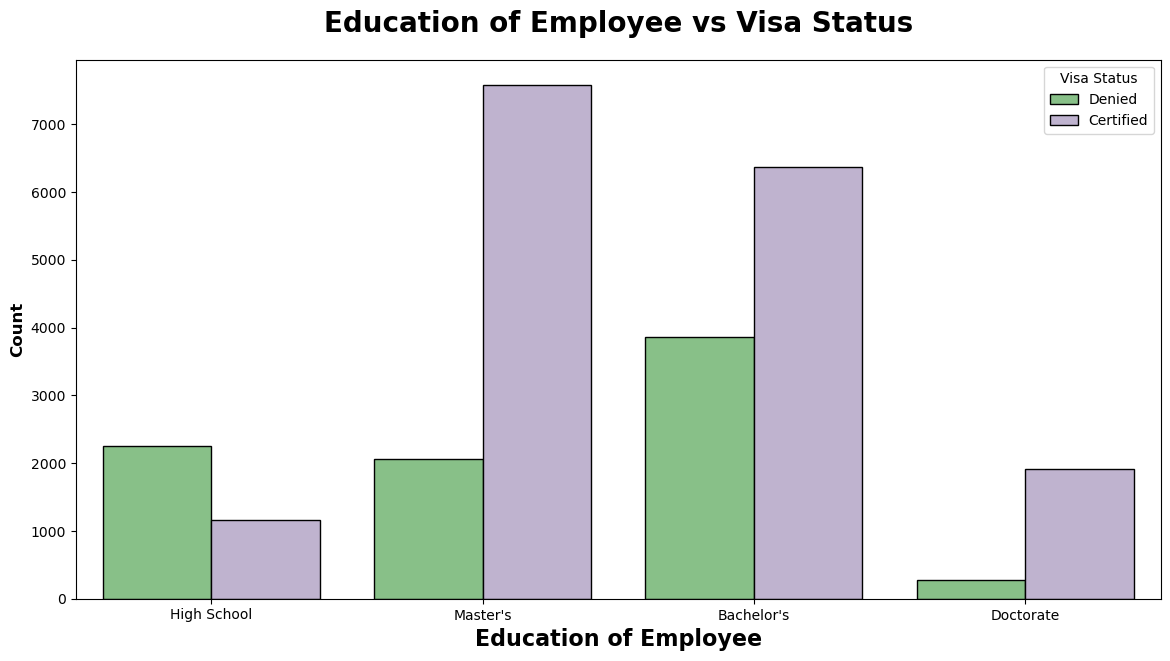

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.subplots(figsize=(14, 7))

# Count plot
sns.countplot(x="education_of_employee",
              hue="case_status",
              data=df,
              ec="black",
              palette="Accent")

# Title
plt.title("Education of Employee vs Visa Status",
          weight="bold",
          fontsize=20,
          pad=20)

# Y-axis label
plt.ylabel("Count",
           weight="bold",
           fontsize=12)

# X-axis label
plt.xlabel("Education of Employee",
           weight="bold",
           fontsize=16)

# Legend
plt.legend(title="Visa Status",
           fancybox=True)

# Show plot
plt.show()

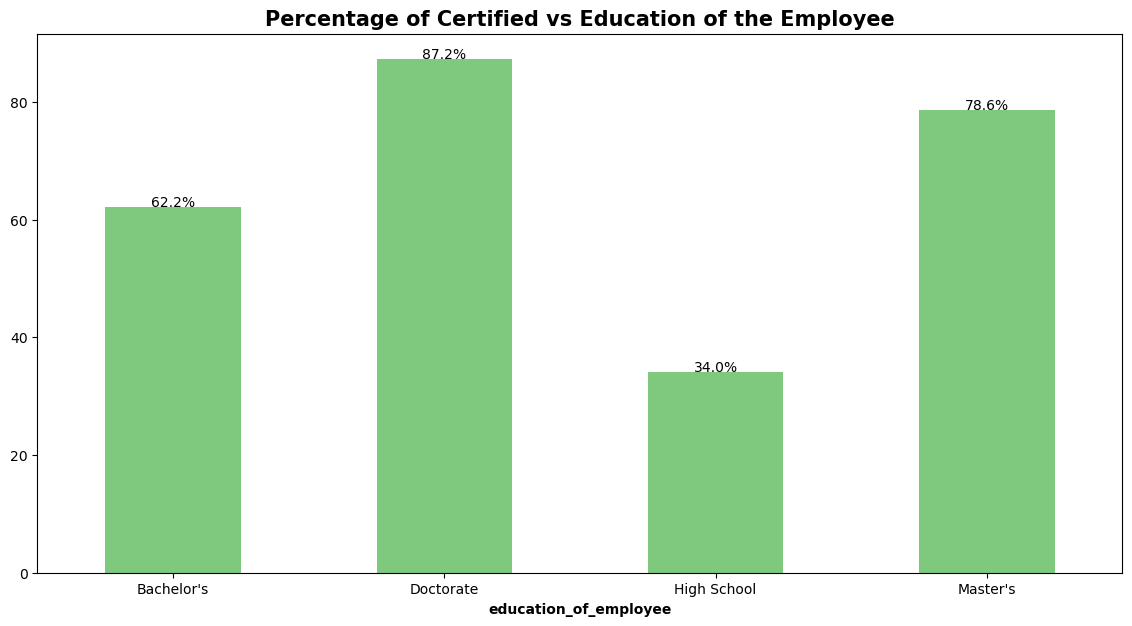

In [30]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=[14, 7])

# Calculate percentage of Certified cases by education
education_percent = (
    100 * df2[df2["case_status"].isin(['Certified'])]['education_of_employee'].value_counts()
    / df2['education_of_employee'].value_counts()
)

# Plot bar chart
education_percent.plot(
    kind='bar',
    stacked=True,
    colormap='Accent'
)

# Title
plt.title("Percentage of Certified vs Education of the Employee",
          fontsize=15,
          fontweight='bold')

# Store values for annotation
order1 = education_percent.values

# Add percentage labels on bars
for n in range(len(order1)):
    count = order1[n]
    strt = '{:0.1f}%'.format(count)

    plt.text(n, count + 0.1, strt, ha='center')

# X-axis label
plt.xlabel('education_of_employee',
           fontweight='bold')

# Rotate x labels
plt.xticks(rotation=0)

# Show plot
plt.show()

In [31]:
# Group data by job experience and case status
job_exp_status = (
    df.groupby('has_job_experience')['case_status']
      .value_counts(normalize=True)
      .to_frame()
)

# Display output
print(job_exp_status)

                                proportion
has_job_experience case_status            
N                  Certified      0.561341
                   Denied         0.438659
Y                  Certified      0.744764
                   Denied         0.255236


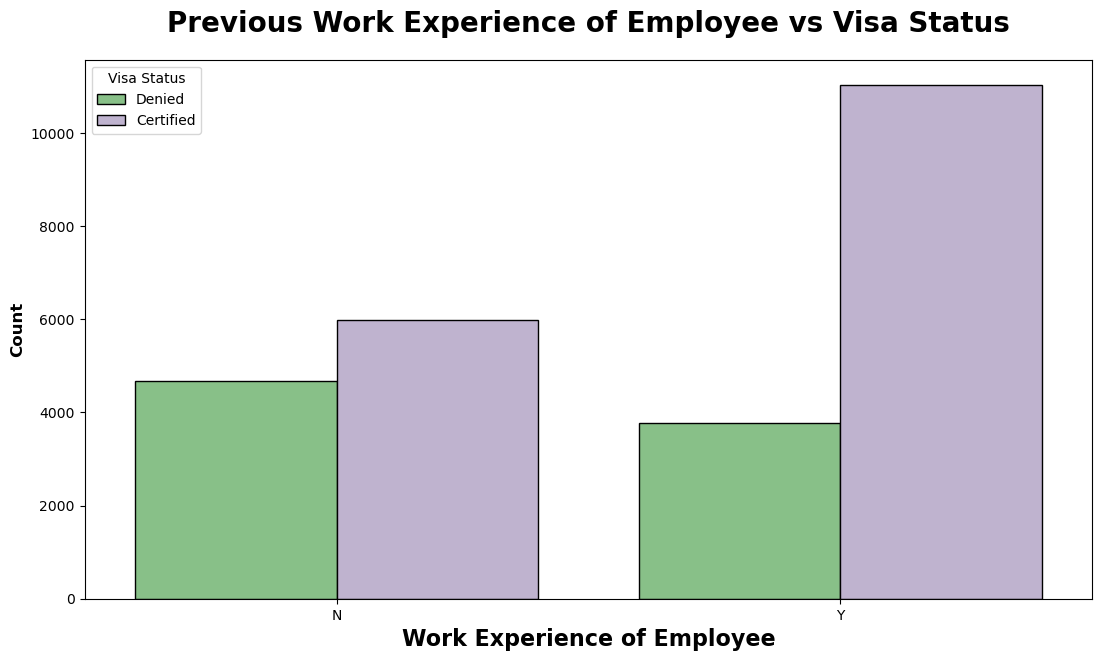

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.subplots(figsize=(13, 7))

# Count plot
sns.countplot(x="has_job_experience",
              hue="case_status",
              data=df,
              ec="black",
              palette="Accent")

# Title
plt.title("Previous Work Experience of Employee vs Visa Status",
          weight="bold",
          fontsize=20,
          pad=20)

# Y-axis label
plt.ylabel("Count",
           weight="bold",
           fontsize=12)

# X-axis label
plt.xlabel("Work Experience of Employee",
           weight="bold",
           fontsize=16)

# Legend
plt.legend(title="Visa Status",
           fancybox=True)

# Show plot
plt.show()

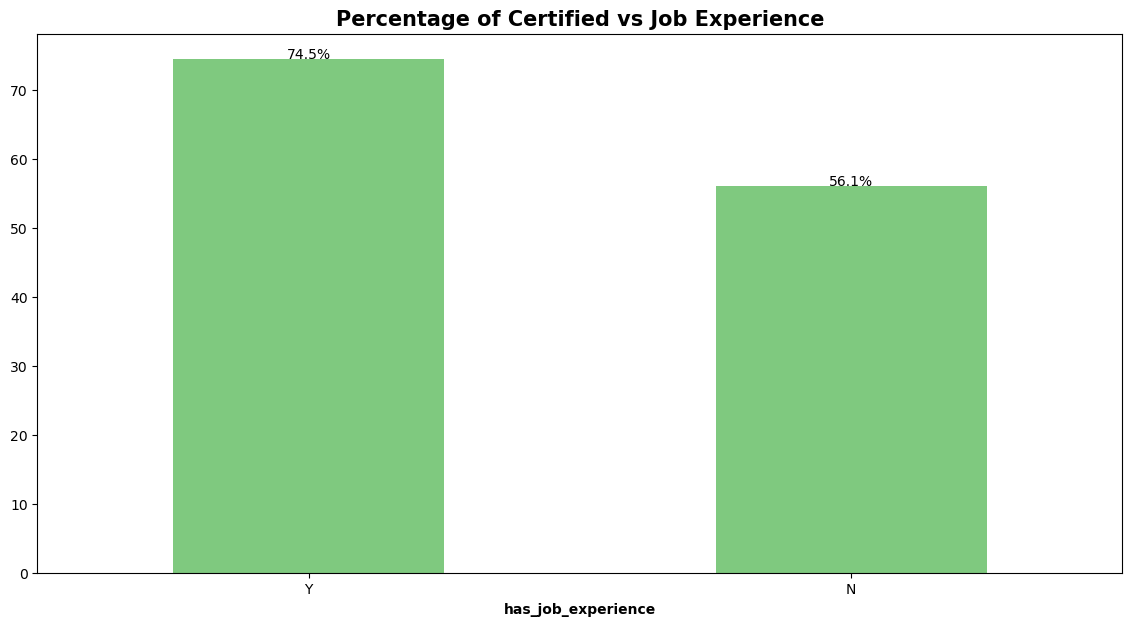

In [33]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=[14, 7])

# Calculate percentage of Certified cases by job experience
job_exp_percent = (
    100 * df2[df2["case_status"].isin(['Certified'])]['has_job_experience'].value_counts()
    / df2['has_job_experience'].value_counts()
)

# Plot bar chart
job_exp_percent.plot(
    kind='bar',
    stacked=True,
    colormap='Accent'
)

# Title
plt.title("Percentage of Certified vs Job Experience",
          fontsize=15,
          fontweight='bold')

# Store values for annotation
order1 = job_exp_percent.values

# Add percentage labels on bars
for n in range(len(order1)):
    count = order1[n]
    strt = '{:0.1f}%'.format(count)

    plt.text(n, count + 0.1, strt, ha='center')

# X-axis label
plt.xlabel('has_job_experience',
           fontweight='bold')

# Rotate x labels
plt.xticks(rotation=0)

# Show plot
plt.show()

In [34]:
# Group data by job training requirement and case status
job_training_status = (
    df.groupby('requires_job_training')['case_status']
      .value_counts(normalize=True)
      .to_frame()
)

# Display output
print(job_training_status)

                                   proportion
requires_job_training case_status            
N                     Certified      0.666459
                      Denied         0.333541
Y                     Certified      0.678849
                      Denied         0.321151


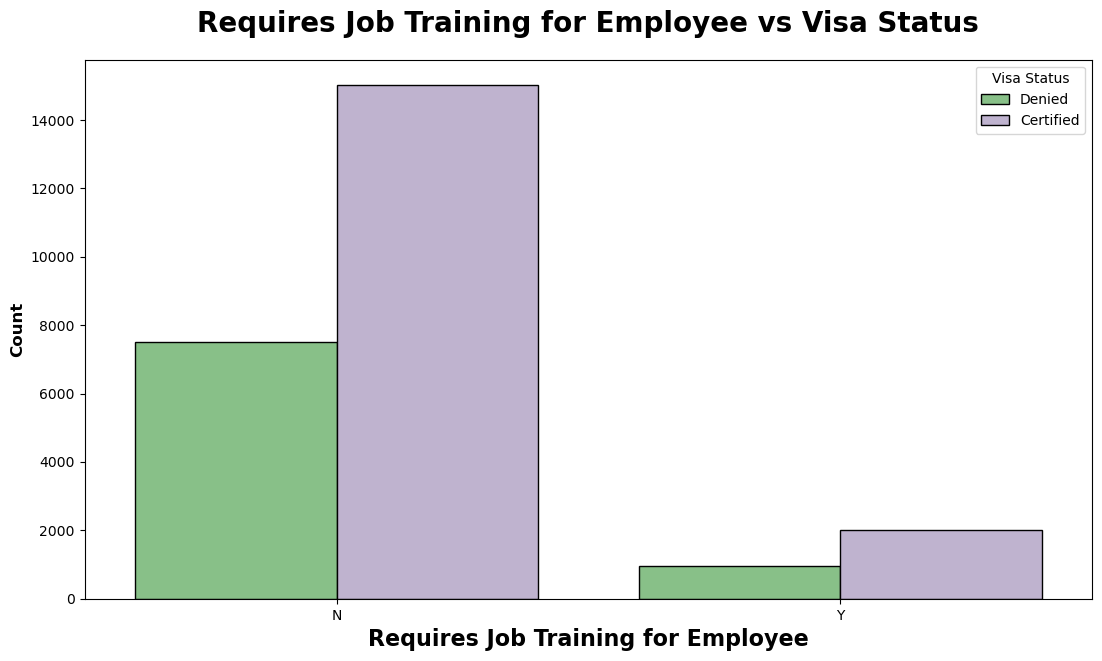

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.subplots(figsize=(13, 7))

# Count plot
sns.countplot(x="requires_job_training",
              hue="case_status",
              data=df,
              ec="black",
              palette="Accent")

# Title
plt.title("Requires Job Training for Employee vs Visa Status",
          weight="bold",
          fontsize=20,
          pad=20)

# Y-axis label
plt.ylabel("Count",
           weight="bold",
           fontsize=12)

# X-axis label
plt.xlabel("Requires Job Training for Employee",
           weight="bold",
           fontsize=16)

# Legend
plt.legend(title="Visa Status",
           fancybox=True)

# Show plot
plt.show()

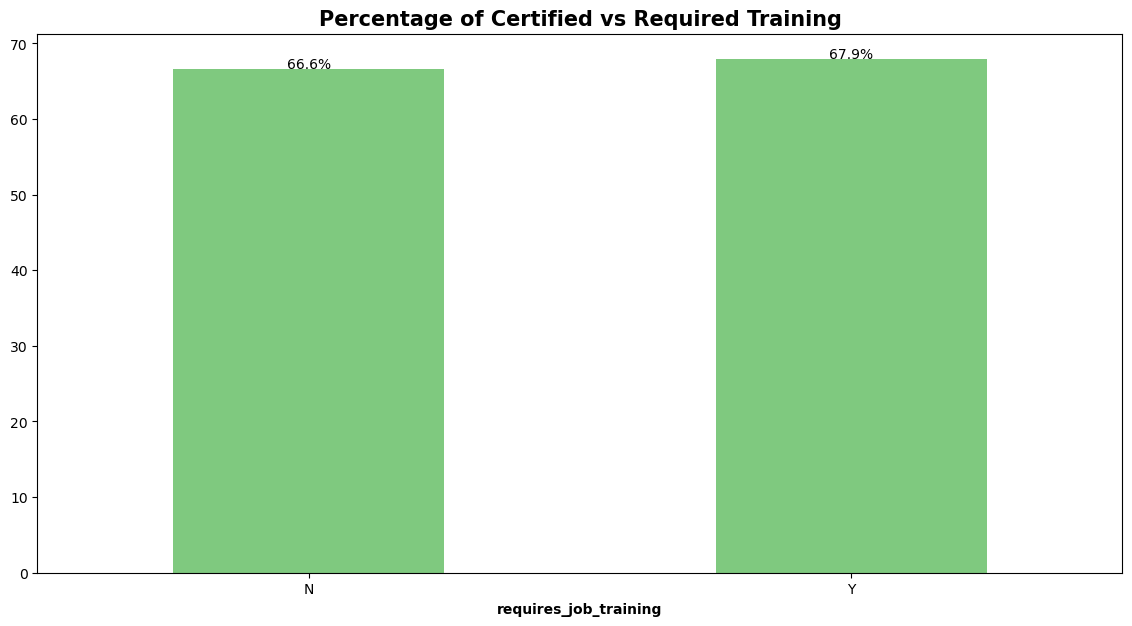

In [37]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=[14, 7])

# Calculate percentage of Certified cases by required job training
training_percent = (
    100 * df2[df2["case_status"].isin(['Certified'])]['requires_job_training'].value_counts()
    / df2['requires_job_training'].value_counts()
)

# Plot bar chart
training_percent.plot(
    kind='bar',
    stacked=True,
    colormap='Accent'
)

# Title
plt.title("Percentage of Certified vs Required Training",
          fontsize=15,
          fontweight='bold')

# Store values for annotation
order1 = training_percent.values

# Add percentage labels on bars
for n in range(len(order1)):
    count = order1[n]
    strt = '{:0.1f}%'.format(count)

    plt.text(n, count + 0.1, strt, ha='center')

# X-axis label
plt.xlabel('requires_job_training',
           fontweight='bold')

# Rotate x-axis labels
plt.xticks(rotation=0)

# Show plot
plt.show()

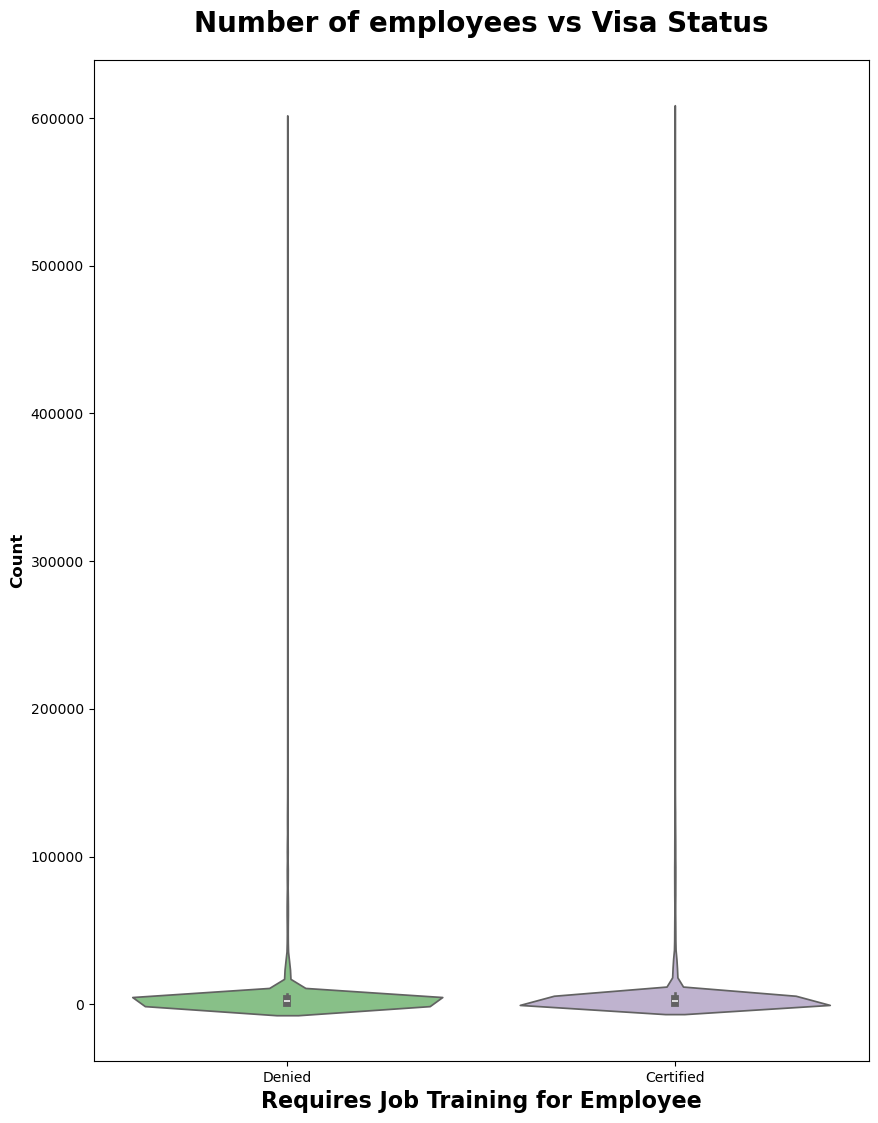

In [38]:
plt.subplots(figsize=(10,13))
sns.violinplot(x="case_status",y='no_of_employees', data=df, palette="Accent")
plt.title("Number of employees vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Requires Job Training for Employee", weight="bold", fontsize=16)
plt.ylim()
plt.show()

In [39]:

#group data by unit_of_wage and count the case_status
df.groupby('unit_of_wage')['case_status'].value_counts(normalize=True)

unit_of_wage  case_status
Hour          Denied         0.653686
              Certified      0.346314
Month         Certified      0.617978
              Denied         0.382022
Week          Certified      0.621324
              Denied         0.378676
Year          Certified      0.698850
              Denied         0.301150
Name: proportion, dtype: float64

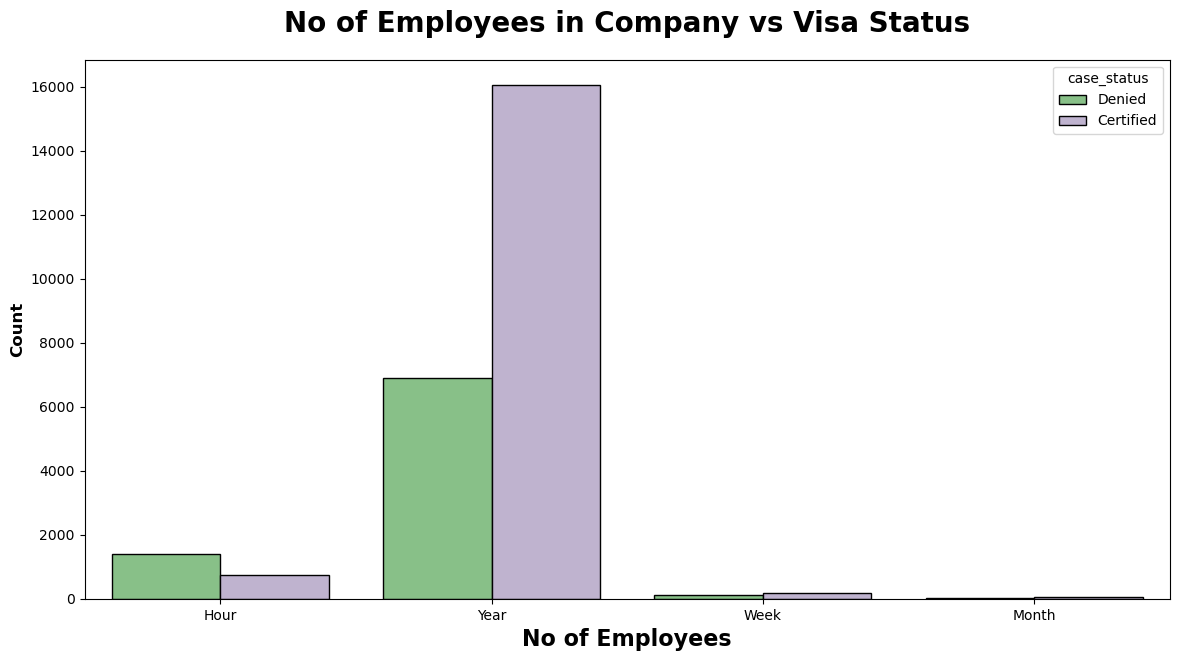

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.subplots(figsize=(14, 7))

# Count plot
sns.countplot(x="unit_of_wage",
              hue="case_status",
              data=df,
              ec='k',
              palette='Accent')

# Title
plt.title("No of Employees in Company vs Visa Status",
          weight="bold",
          fontsize=20,
          pad=20)

# X-axis label
plt.xlabel("No of Employees",
           weight="bold",
           fontsize=16)

# Y-axis label
plt.ylabel("Count",
           weight="bold",
           fontsize=12)

# Show plot
plt.show()

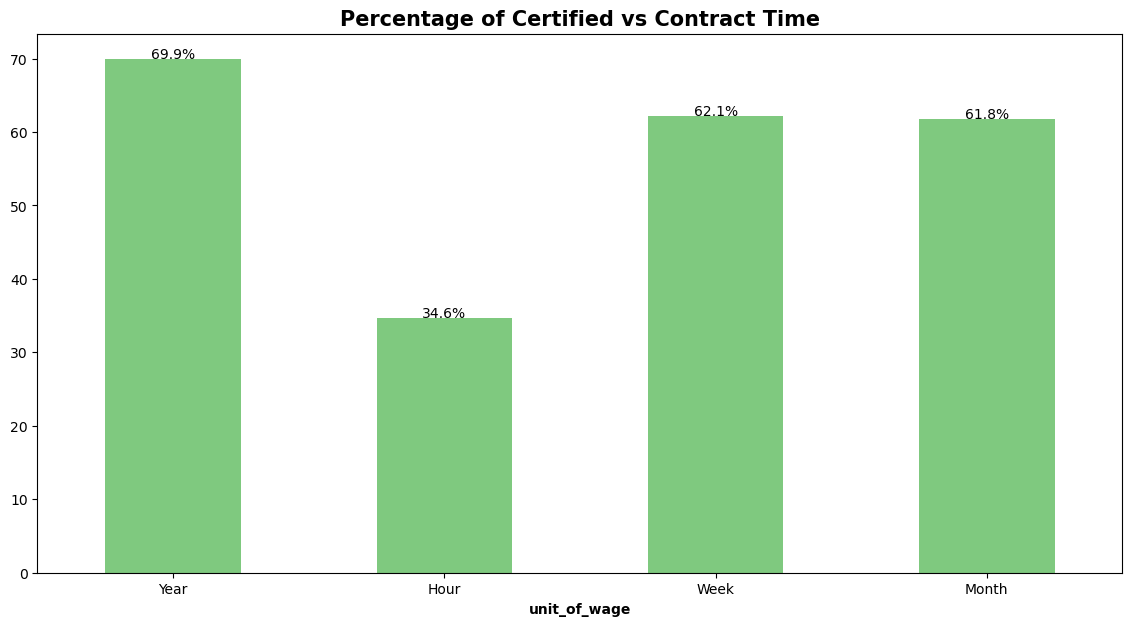

In [41]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=[14, 7])

# Calculate percentage of Certified cases by unit of wage
wage_percent = (
    100 * df2[df2["case_status"].isin(['Certified'])]['unit_of_wage'].value_counts()
    / df2['unit_of_wage'].value_counts()
)

# Plot bar chart
wage_percent.plot(
    kind='bar',
    stacked=True,
    colormap='Accent'
)

# Title
plt.title("Percentage of Certified vs Contract Time",
          fontsize=15,
          fontweight='bold')

# Store values for annotation
order1 = wage_percent.values

# Add percentage labels on bars
for n in range(len(order1)):
    count = order1[n]
    strt = '{:0.1f}%'.format(count)

    plt.text(n, count + 0.1, strt, ha='center')

# X-axis label
plt.xlabel('unit_of_wage',
           fontweight='bold')

# Rotate x-axis labels
plt.xticks(rotation=0)

# Show plot
plt.show()

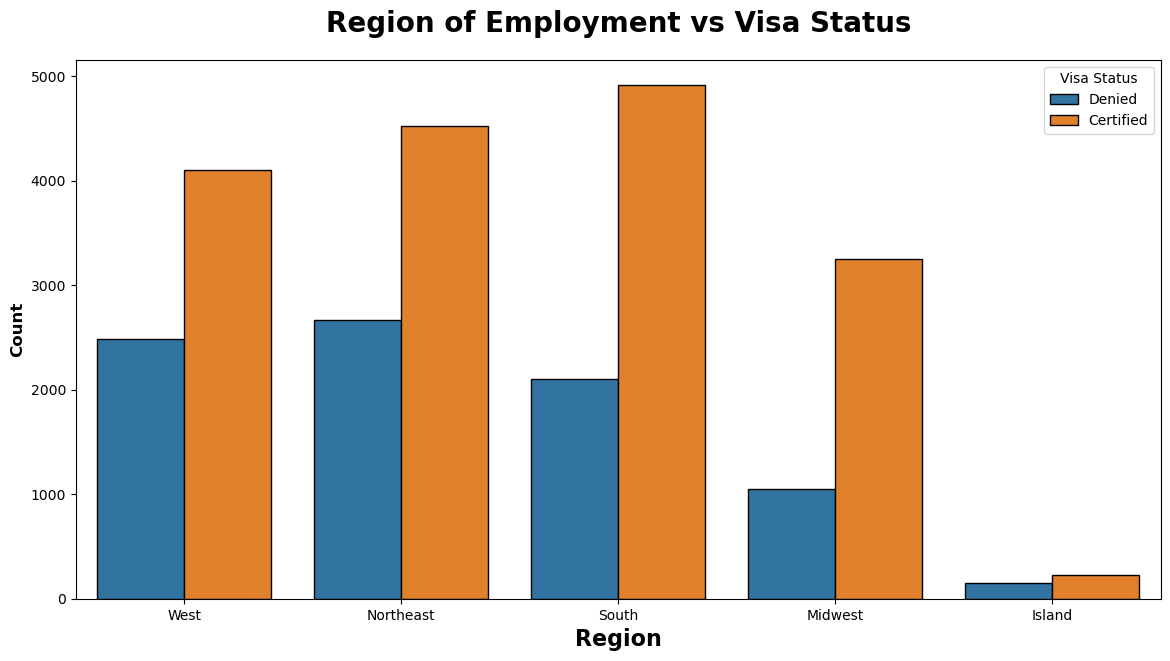

In [42]:
plt.subplots(figsize=(14,7))
sns.countplot(x="region_of_employment",hue="case_status", data=df,ec='k')
plt.title("Region of Employment vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Region", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

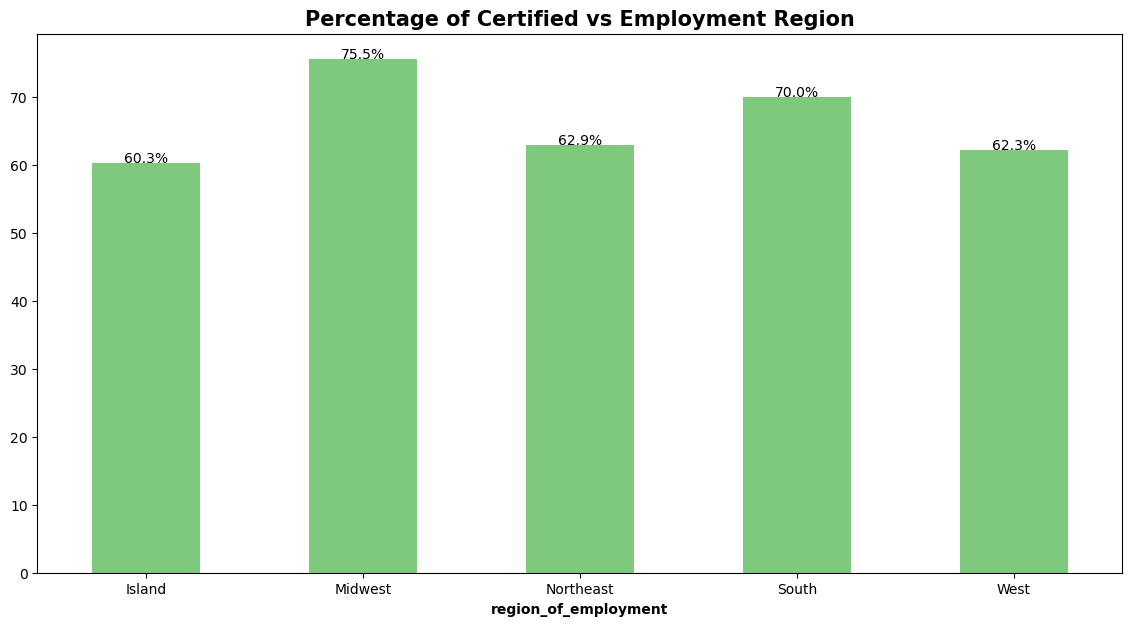

In [43]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=[14, 7])

# Calculate percentage of Certified cases by employment region
region_percent = (
    100 * df2[df2["case_status"].isin(['Certified'])]['region_of_employment'].value_counts()
    / df2['region_of_employment'].value_counts()
)

# Plot bar chart
region_percent.plot(
    kind='bar',
    stacked=True,
    colormap='Accent'
)

# Title
plt.title("Percentage of Certified vs Employment Region",
          fontsize=15,
          fontweight='bold')

# Store values for annotation
order1 = region_percent.values

# Add percentage labels on bars
for n in range(len(order1)):
    count = order1[n]
    strt = '{:0.1f}%'.format(count)

    plt.text(n, count + 0.1, strt, ha='center')

# X-axis label
plt.xlabel('region_of_employment',
           fontweight='bold')

# Rotate x-axis labels
plt.xticks(rotation=0)

# Show plot
plt.show()

In [44]:
df.groupby('prevailing_wage').case_status.value_counts()

prevailing_wage  case_status
2.1367           Certified      1
2.9561           Denied         1
3.0031           Denied         1
3.3188           Denied         1
3.4889           Certified      1
                               ..
311734.4900      Certified      1
314156.0600      Certified      1
315497.6000      Certified      1
318446.0500      Certified      1
319210.2700      Denied         1
Name: count, Length: 25462, dtype: int64

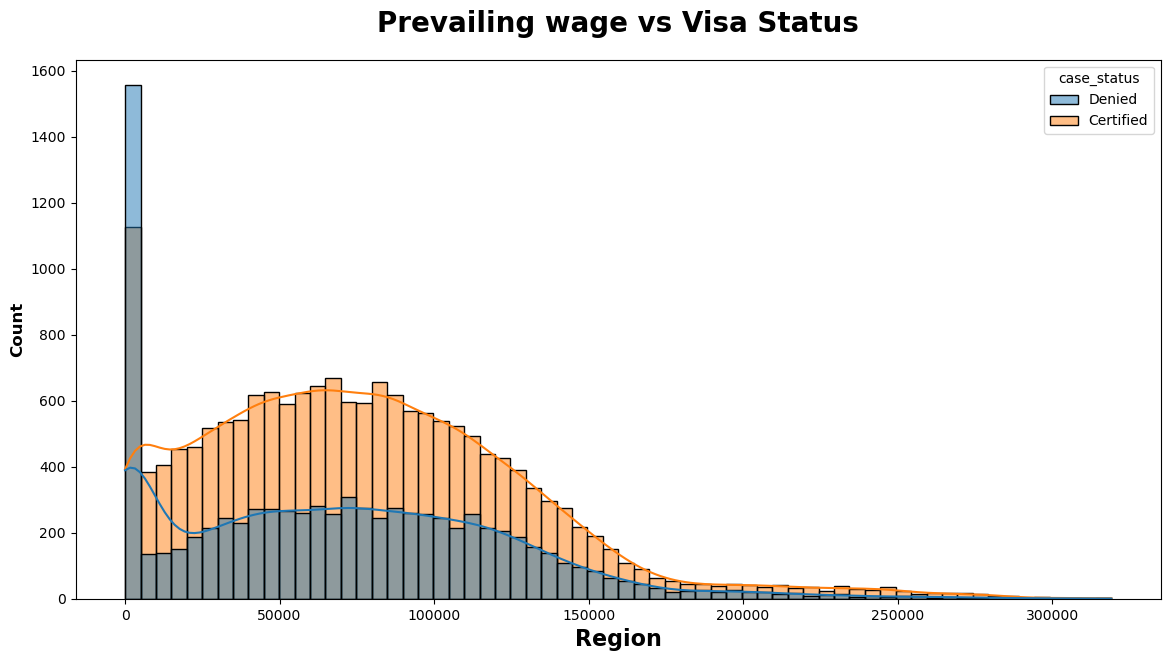

In [45]:
plt.subplots(figsize=(14,7))
sns.histplot(x="prevailing_wage",hue="case_status", data=df, kde=True)
plt.title("Prevailing wage vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Region", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()

In [46]:
print('Average Prevailing wage based on Employee education')

# Calculate average wage by education and sort values
avg_wage = (
    df.groupby('education_of_employee')['prevailing_wage']
      .mean()
      .to_frame()
      .sort_values(by='prevailing_wage', ascending=False)
)

# Display result
print(avg_wage)

Average Prevailing wage based on Employee education
                       prevailing_wage
education_of_employee                 
Master's                  78843.057843
Bachelor's                73405.443735
High School               71582.147756
Doctorate                 64561.076657


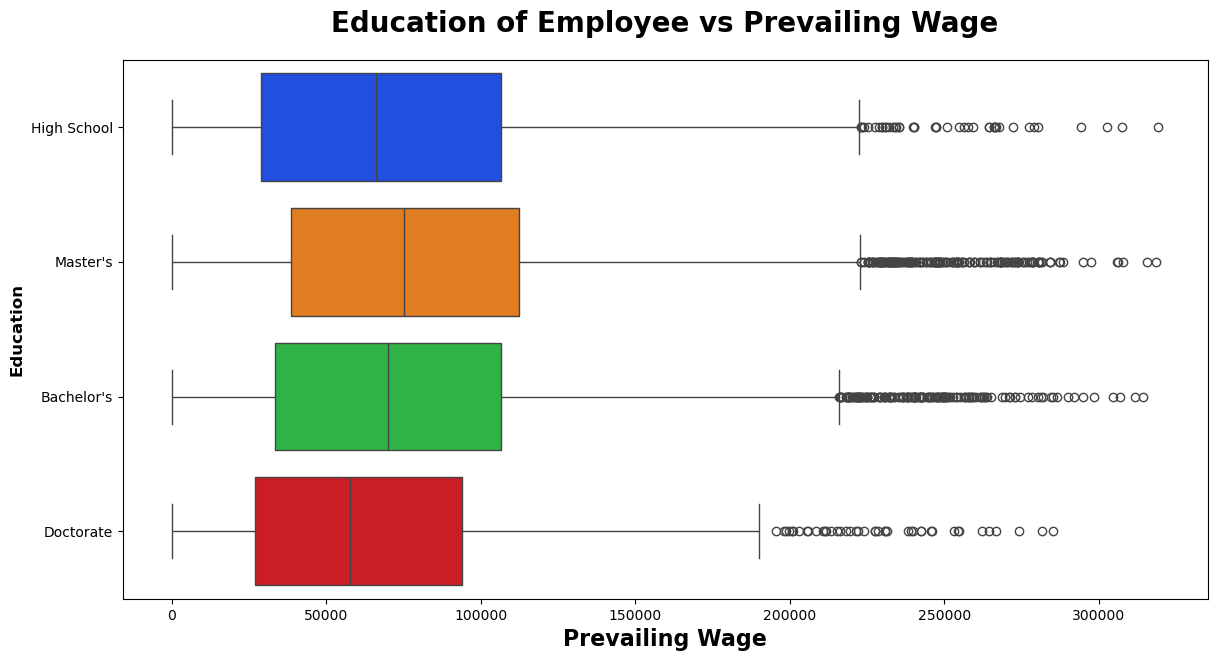

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.subplots(figsize=(14, 7))

# Boxplot
sns.boxplot(y="education_of_employee",
            x="prevailing_wage",
            data=df,
            palette='bright')

# Title
plt.title("Education of Employee vs Prevailing Wage",
          weight="bold",
          fontsize=20,
          pad=20)

# X-axis label
plt.xlabel("Prevailing Wage",
           weight="bold",
           fontsize=16)

# Y-axis label
plt.ylabel("Education",
           weight="bold",
           fontsize=12)

# Show plot
plt.show()

In [49]:
print('Median Prevailing wage based on Job experience')

# Calculate median wage by job experience and sort values
median_wage = (
    df.groupby('has_job_experience')['prevailing_wage']
      .median()
      .to_frame()
      .sort_values(by='prevailing_wage', ascending=False)
)

# Display result
print(median_wage)

Median Prevailing wage based on Job experience
                    prevailing_wage
has_job_experience                 
N                         72602.290
Y                         69033.665


In [50]:
print('Average Prevailing wage based on Continent')

# Calculate average wage by continent and sort values
avg_wage_continent = (
    df.groupby('continent')['prevailing_wage']
      .mean()
      .to_frame()
      .sort_values(by='prevailing_wage', ascending=False)
)

# Display result
print(avg_wage_continent)

Average Prevailing wage based on Continent
               prevailing_wage
continent                     
Asia              79543.021780
Africa            77425.923450
Oceania           75994.276719
North America     68066.319257
South America     60209.575314
Europe            59842.925899


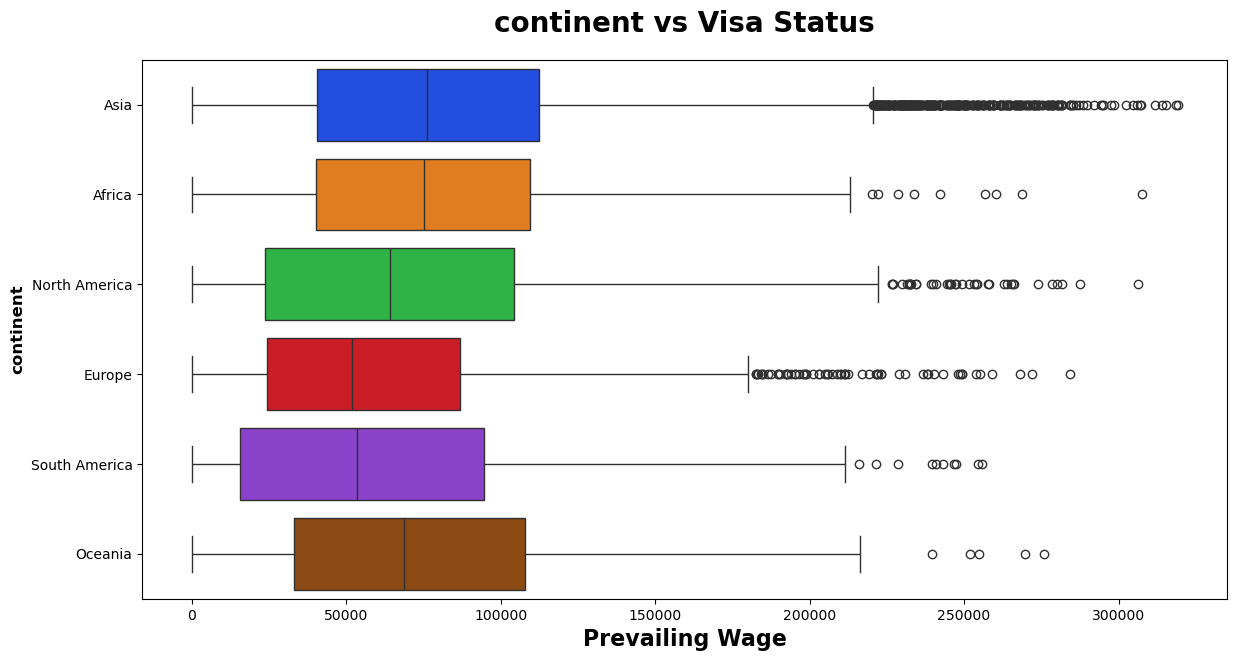

In [51]:
plt.subplots(figsize=(14,7))
sns.boxplot(y="continent",x = "prevailing_wage", data=df,palette='bright')
plt.title("continent vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)
plt.ylabel("continent", weight="bold", fontsize=12)
plt.show()

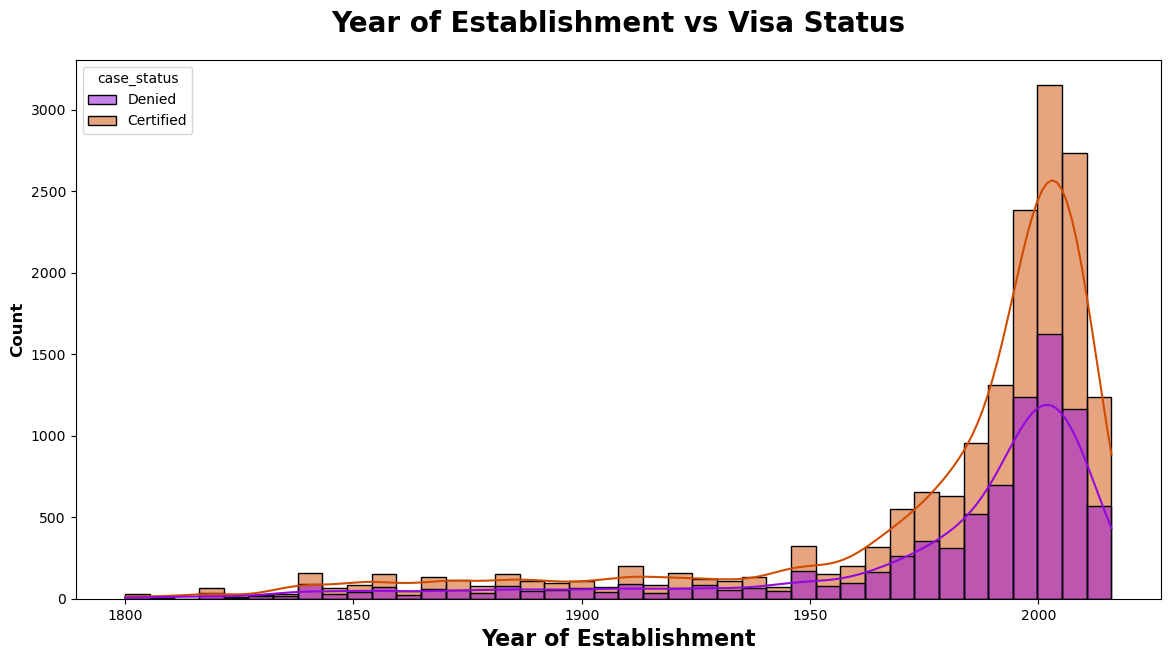

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.subplots(figsize=(14, 7))

# Histogram plot
sns.histplot(x="yr_of_estab",
             data=df,
             bins=40,
             hue='case_status',
             palette='gnuplot',
             kde=True)

# Title
plt.title("Year of Establishment vs Visa Status",
          weight="bold",
          fontsize=20,
          pad=20)

# X-axis label
plt.xlabel("Year of Establishment",
           weight="bold",
           fontsize=16)

# Y-axis label
plt.ylabel("Count",
           weight="bold",
           fontsize=12)

# Show plot
plt.show()